# CycleGAN for Unpaired Image-to-Image Translation

## Problem Statement

The goal of this notebook is to build a CycleGAN that learns image-to-image translation between two unpaired image domains.

CycleGAN is designed for situations where paired training examples are not available. For example, we may have images from Domain A and images from Domain B, but not exact matching pairs.

In this notebook, we create two simple unpaired domains from MNIST:

- Domain A: normal MNIST handwritten digit images.
- Domain B: inverted MNIST handwritten digit images.

The CycleGAN learns to translate normal digits into inverted digits and inverted digits back into normal digits.

## Objectives

By the end of this notebook, we will:

1. Load and preprocess MNIST images.
2. Create two unpaired image domains.
3. Build two Generator models for bidirectional translation.
4. Build two Discriminator models, one for each domain.
5. Train the CycleGAN using adversarial loss, cycle-consistency loss, and identity loss.
6. Visualize image translation results from both directions.
7. Understand how CycleGAN learns without paired examples.

## Expected Outcome

After training, the model should learn two mappings:

- Normal digit image to inverted digit image.
- Inverted digit image to normal digit image.

Because this notebook uses a compact dataset and a small architecture for demonstration, the output may not be perfect after a few epochs. However, the learned transformation should become visually clear as training progresses.

## 1. Import Required Libraries

This notebook uses TensorFlow/Keras, NumPy, and Matplotlib. These libraries are available in Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make the experiment reproducible as much as possible.
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Prepare Two Image Domains

CycleGAN requires two image domains. To keep this notebook fast and reliable in Colab, we use MNIST and create an inverted version of MNIST.

The two domains are intentionally shuffled independently so the model does not receive paired examples.

In [2]:
# Load MNIST images. Labels are not required for CycleGAN training.
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Use a subset to keep training fast for a Colab demonstration.
NUM_SAMPLES = 10000
x_train = x_train[:NUM_SAMPLES].astype("float32")

# Scale real images from [0, 255] to [-1, 1].
domain_a = (x_train - 127.5) / 127.5

# Create Domain B by inverting Domain A in the normalized range.
domain_b = -domain_a

# Add channel dimension: (samples, height, width, channels).
domain_a = np.expand_dims(domain_a, axis=-1)
domain_b = np.expand_dims(domain_b, axis=-1)

# Shuffle Domain B independently to remove direct pair ordering.
domain_b = np.random.permutation(domain_b)

print("Domain A shape:", domain_a.shape)
print("Domain B shape:", domain_b.shape)
print("Domain A value range:", domain_a.min(), domain_a.max())
print("Domain B value range:", domain_b.min(), domain_b.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Domain A shape: (10000, 28, 28, 1)
Domain B shape: (10000, 28, 28, 1)
Domain A value range: -1.0 1.0
Domain B value range: -1.0 1.0


## 3. Visualize the Two Domains

Domain A contains normal MNIST digits. Domain B contains inverted MNIST digits.

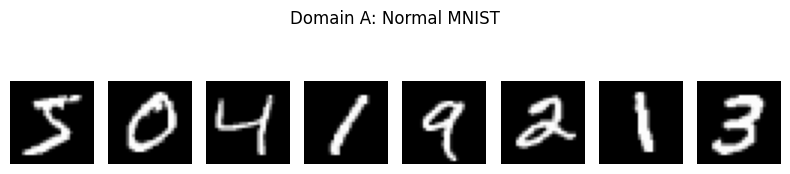

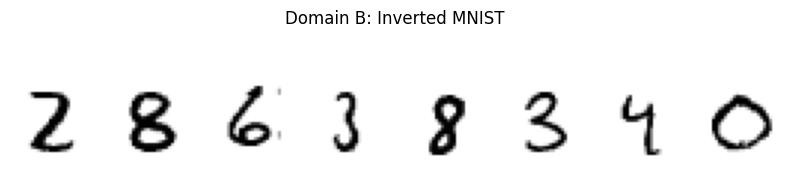

In [3]:
def show_domain_examples(images, title):
    """Displays sample images from one domain."""
    plt.figure(figsize=(8, 2))
    for i in range(8):
        plt.subplot(1, 8, i + 1)
        plt.imshow((images[i, :, :, 0] + 1.0) / 2.0, cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_domain_examples(domain_a, "Domain A: Normal MNIST")
show_domain_examples(domain_b, "Domain B: Inverted MNIST")

## 4. Define Hyperparameters

CycleGAN uses multiple losses. The cycle-consistency loss is especially important because it encourages translated images to preserve the original image content.

In [4]:
IMAGE_SHAPE = (28, 28, 1)
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Cycle-consistency weight. This helps preserve digit structure after round-trip translation.
LAMBDA_CYCLE = 10.0

# Identity loss weight. This helps each Generator avoid unnecessary changes for images already in the target domain.
LAMBDA_IDENTITY = 5.0

## 5. Prepare the Training Dataset

The dataset returns one batch from Domain A and one independently shuffled batch from Domain B. These are unpaired examples.

In [5]:
dataset_a = tf.data.Dataset.from_tensor_slices(domain_a).shuffle(NUM_SAMPLES).batch(BATCH_SIZE, drop_remainder=True)
dataset_b = tf.data.Dataset.from_tensor_slices(domain_b).shuffle(NUM_SAMPLES).batch(BATCH_SIZE, drop_remainder=True)

train_dataset = tf.data.Dataset.zip((dataset_a, dataset_b)).prefetch(tf.data.AUTOTUNE)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 156


## 6. Build the Generator

CycleGAN uses two Generators:

- `G_AB`: translates images from Domain A to Domain B.
- `G_BA`: translates images from Domain B to Domain A.

This compact Generator uses convolution layers to encode the image and transposed convolution layers to reconstruct the translated image.

In [6]:
def build_generator(name):
    """Builds a compact image-to-image Generator."""
    inputs = layers.Input(shape=IMAGE_SHAPE)

    # Encoder: reduce spatial size while increasing feature depth.
    x = layers.Conv2D(32, kernel_size=4, strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    # Bottleneck: learn compact image representation.
    x = layers.Conv2D(128, kernel_size=3, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder: restore spatial size.
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # tanh keeps generated pixels in the same [-1, 1] range as training images.
    outputs = layers.Conv2D(1, kernel_size=3, strides=1, padding="same", activation="tanh")(x)

    return models.Model(inputs, outputs, name=name)


generator_ab = build_generator("Generator_A_to_B")
generator_ba = build_generator("Generator_B_to_A")

generator_ab.summary()

Model: "Generator_A_to_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,321 (1.04 MB)

 Trainable params: 271,745 (1.04 MB)

 Non-trainable params: 576 (2.25 KB)

## 7. Build the Discriminator

CycleGAN uses one Discriminator per domain:

- `D_A`: decides whether images belong to real Domain A.
- `D_B`: decides whether images belong to real Domain B.

Each Discriminator outputs a patch-level score map rather than a single scalar. This is a compact PatchGAN-style Discriminator.

In [7]:
def build_discriminator(name):
    """Builds a compact PatchGAN-style Discriminator."""
    inputs = layers.Input(shape=IMAGE_SHAPE)

    x = layers.Conv2D(32, kernel_size=4, strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, kernel_size=3, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    # Patch-level real/fake logits. No sigmoid is used because the loss expects logits.
    outputs = layers.Conv2D(1, kernel_size=3, strides=1, padding="same")(x)

    return models.Model(inputs, outputs, name=name)


discriminator_a = build_discriminator("Discriminator_A")
discriminator_b = build_discriminator("Discriminator_B")

discriminator_a.summary()

Model: "Discriminator_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 1)        │         1,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,961 (425.63 KB)

 Trainable params: 108,577 (424.13 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Configure Loss Functions and Optimizers

CycleGAN combines three main loss types:

1. Adversarial loss: makes translated images look like the target domain.
2. Cycle-consistency loss: makes A to B to A reconstruct the original A, and B to A to B reconstruct the original B.
3. Identity loss: discourages unnecessary changes when an image is already in the target domain.

In [8]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

generator_ab_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
generator_ba_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_a_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_b_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def generator_adversarial_loss(fake_output):
    """Encourages generated images to be classified as real."""
    return binary_cross_entropy(tf.ones_like(fake_output), fake_output)


def discriminator_loss(real_output, fake_output):
    """Trains a Discriminator to separate real images from translated images."""
    real_loss = binary_cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
    return 0.5 * (real_loss + fake_loss)


def cycle_consistency_loss(real_image, cycled_image):
    """Encourages round-trip translation to reconstruct the original image."""
    return LAMBDA_CYCLE * tf.reduce_mean(tf.abs(real_image - cycled_image))


def identity_loss(real_image, same_image):
    """Encourages a Generator to preserve images already in the target domain."""
    return LAMBDA_IDENTITY * tf.reduce_mean(tf.abs(real_image - same_image))

## 9. Define the Training Step

Each CycleGAN training step performs both translation directions:

- A to B to A
- B to A to B

This cycle structure is what allows the model to learn from unpaired images.

In [9]:
@tf.function
def train_step(real_a, real_b):
    """Runs one CycleGAN training step."""
    with tf.GradientTape(persistent=True) as tape:
        # Translate images across domains.
        fake_b = generator_ab(real_a, training=True)
        fake_a = generator_ba(real_b, training=True)

        # Reconstruct original images after a full cycle.
        cycled_a = generator_ba(fake_b, training=True)
        cycled_b = generator_ab(fake_a, training=True)

        # Identity mappings help preserve target-domain images.
        same_a = generator_ba(real_a, training=True)
        same_b = generator_ab(real_b, training=True)

        # Discriminator outputs for real and translated images.
        disc_real_a = discriminator_a(real_a, training=True)
        disc_real_b = discriminator_b(real_b, training=True)
        disc_fake_a = discriminator_a(fake_a, training=True)
        disc_fake_b = discriminator_b(fake_b, training=True)

        # Generator adversarial losses.
        gen_ab_adv_loss = generator_adversarial_loss(disc_fake_b)
        gen_ba_adv_loss = generator_adversarial_loss(disc_fake_a)

        # Cycle-consistency losses for both directions.
        total_cycle_loss = (
            cycle_consistency_loss(real_a, cycled_a)
            + cycle_consistency_loss(real_b, cycled_b)
        )

        # Identity losses for both Generators.
        total_identity_loss = identity_loss(real_a, same_a) + identity_loss(real_b, same_b)

        # Total Generator losses.
        total_gen_ab_loss = gen_ab_adv_loss + total_cycle_loss + total_identity_loss
        total_gen_ba_loss = gen_ba_adv_loss + total_cycle_loss + total_identity_loss

        # Discriminator losses.
        disc_a_loss = discriminator_loss(disc_real_a, disc_fake_a)
        disc_b_loss = discriminator_loss(disc_real_b, disc_fake_b)

    # Calculate gradients for each model.
    generator_ab_gradients = tape.gradient(total_gen_ab_loss, generator_ab.trainable_variables)
    generator_ba_gradients = tape.gradient(total_gen_ba_loss, generator_ba.trainable_variables)
    discriminator_a_gradients = tape.gradient(disc_a_loss, discriminator_a.trainable_variables)
    discriminator_b_gradients = tape.gradient(disc_b_loss, discriminator_b.trainable_variables)

    # Apply model updates.
    generator_ab_optimizer.apply_gradients(zip(generator_ab_gradients, generator_ab.trainable_variables))
    generator_ba_optimizer.apply_gradients(zip(generator_ba_gradients, generator_ba.trainable_variables))
    discriminator_a_optimizer.apply_gradients(zip(discriminator_a_gradients, discriminator_a.trainable_variables))
    discriminator_b_optimizer.apply_gradients(zip(discriminator_b_gradients, discriminator_b.trainable_variables))

    return total_gen_ab_loss, total_gen_ba_loss, disc_a_loss, disc_b_loss

## 10. Helper Function to Display Translations

This function shows the original image, translated image, and reconstructed image for both translation directions.

In [10]:
sample_a = tf.convert_to_tensor(domain_a[:4])
sample_b = tf.convert_to_tensor(domain_b[:4])


def display_translations(epoch):
    """Displays CycleGAN translation examples."""
    fake_b = generator_ab(sample_a, training=False)
    cycled_a = generator_ba(fake_b, training=False)

    fake_a = generator_ba(sample_b, training=False)
    cycled_b = generator_ab(fake_a, training=False)

    rows = [sample_a, fake_b, cycled_a, sample_b, fake_a, cycled_b]
    row_titles = [
        "A Original",
        "A to B",
        "A to B to A",
        "B Original",
        "B to A",
        "B to A to B",
    ]

    plt.figure(figsize=(8, 10))
    for row_index, images in enumerate(rows):
        for col_index in range(4):
            plt.subplot(6, 4, row_index * 4 + col_index + 1)
            plt.imshow((images[col_index, :, :, 0] + 1.0) / 2.0, cmap="gray")
            plt.axis("off")
            if col_index == 0:
                plt.ylabel(row_titles[row_index], fontsize=9)

    plt.suptitle(f"CycleGAN Translations After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 11. Train the CycleGAN

Training updates four models: two Generators and two Discriminators. Generated outputs are displayed at selected epochs to monitor translation quality.

Epoch 01/10 | G_AB: 6.4090 | G_BA: 6.4083 | D_A: 0.5888 | D_B: 0.5945


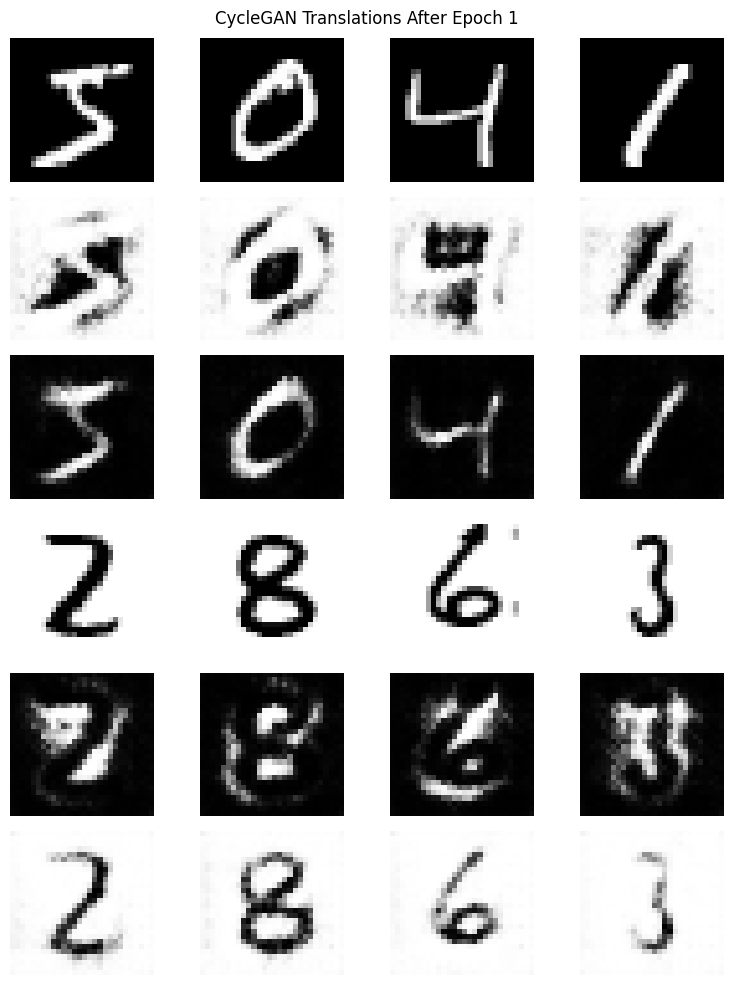

Epoch 02/10 | G_AB: 3.1559 | G_BA: 3.1238 | D_A: 0.5306 | D_B: 0.5162
Epoch 03/10 | G_AB: 3.3572 | G_BA: 3.3437 | D_A: 0.4933 | D_B: 0.4897
Epoch 04/10 | G_AB: 3.4416 | G_BA: 3.4101 | D_A: 0.4955 | D_B: 0.4847
Epoch 05/10 | G_AB: 3.4441 | G_BA: 3.4418 | D_A: 0.4811 | D_B: 0.4829


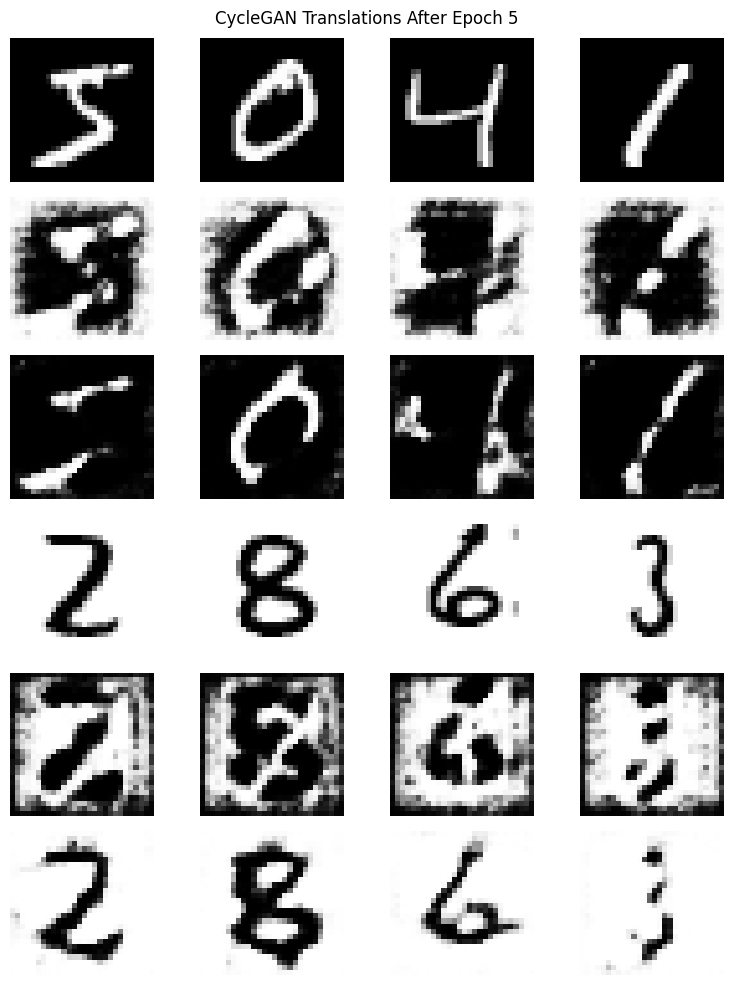

Epoch 06/10 | G_AB: 3.4452 | G_BA: 3.4670 | D_A: 0.4691 | D_B: 0.4796
Epoch 07/10 | G_AB: 3.4443 | G_BA: 3.4814 | D_A: 0.4630 | D_B: 0.4808
Epoch 08/10 | G_AB: 3.4646 | G_BA: 3.5166 | D_A: 0.4589 | D_B: 0.4852
Epoch 09/10 | G_AB: 3.4515 | G_BA: 3.5186 | D_A: 0.4581 | D_B: 0.4904
Epoch 10/10 | G_AB: 3.4500 | G_BA: 3.5349 | D_A: 0.4594 | D_B: 0.4980


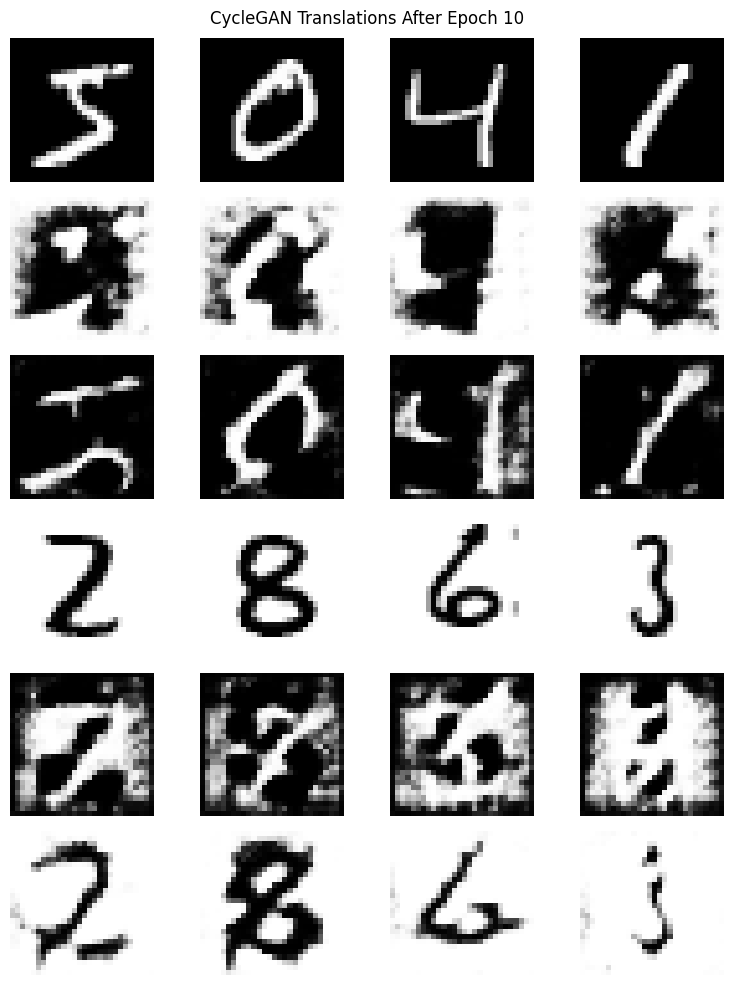

In [11]:
def train(dataset, epochs):
    """Trains the CycleGAN model."""
    generator_ab_losses = []
    generator_ba_losses = []
    discriminator_a_losses = []
    discriminator_b_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_ab_losses = []
        epoch_gen_ba_losses = []
        epoch_disc_a_losses = []
        epoch_disc_b_losses = []

        for real_a, real_b in dataset:
            gen_ab_loss, gen_ba_loss, disc_a_loss, disc_b_loss = train_step(real_a, real_b)

            epoch_gen_ab_losses.append(gen_ab_loss.numpy())
            epoch_gen_ba_losses.append(gen_ba_loss.numpy())
            epoch_disc_a_losses.append(disc_a_loss.numpy())
            epoch_disc_b_losses.append(disc_b_loss.numpy())

        avg_gen_ab_loss = float(np.mean(epoch_gen_ab_losses))
        avg_gen_ba_loss = float(np.mean(epoch_gen_ba_losses))
        avg_disc_a_loss = float(np.mean(epoch_disc_a_losses))
        avg_disc_b_loss = float(np.mean(epoch_disc_b_losses))

        generator_ab_losses.append(avg_gen_ab_loss)
        generator_ba_losses.append(avg_gen_ba_loss)
        discriminator_a_losses.append(avg_disc_a_loss)
        discriminator_b_losses.append(avg_disc_b_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"G_AB: {avg_gen_ab_loss:.4f} | "
            f"G_BA: {avg_gen_ba_loss:.4f} | "
            f"D_A: {avg_disc_a_loss:.4f} | "
            f"D_B: {avg_disc_b_loss:.4f}"
        )

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_translations(epoch)

    return generator_ab_losses, generator_ba_losses, discriminator_a_losses, discriminator_b_losses


generator_ab_losses, generator_ba_losses, discriminator_a_losses, discriminator_b_losses = train(train_dataset, EPOCHS)

## 12. Plot Training Losses

CycleGAN has multiple loss components. These curves help monitor training, while visual translation quality remains the most important practical signal.

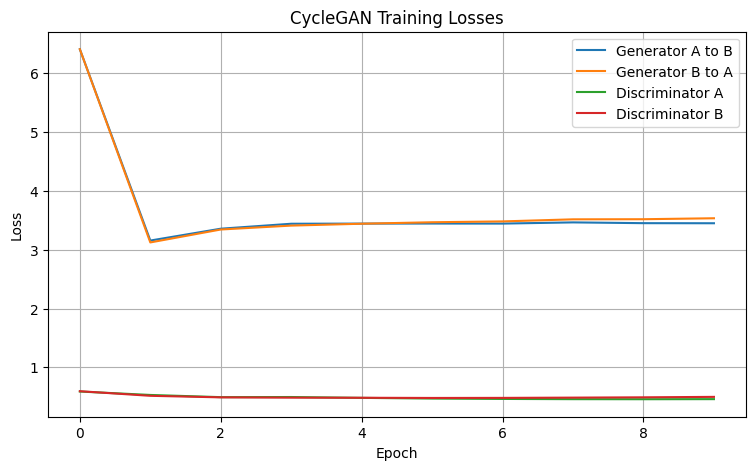

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(generator_ab_losses, label="Generator A to B")
plt.plot(generator_ba_losses, label="Generator B to A")
plt.plot(discriminator_a_losses, label="Discriminator A")
plt.plot(discriminator_b_losses, label="Discriminator B")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 13. Generate Final Translations

The trained Generators can now translate images in both directions.

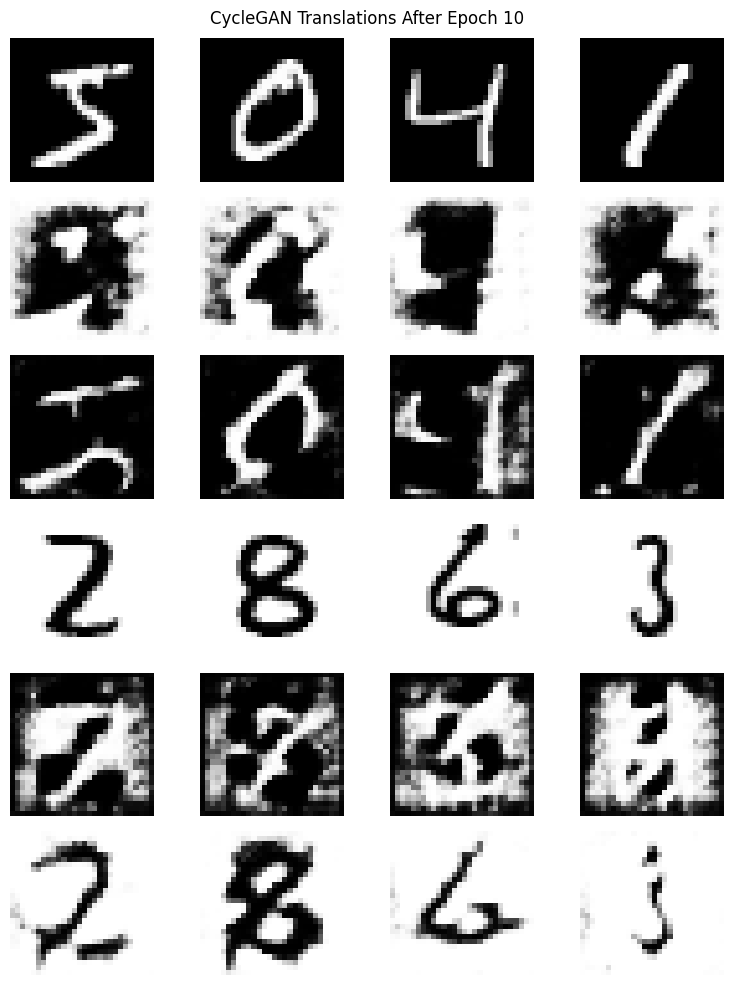

In [13]:
display_translations(EPOCHS)

## Conclusion

This notebook implemented a CycleGAN for unpaired image-to-image translation between normal MNIST digits and inverted MNIST digits.

The model used two Generators and two Discriminators. The Generators learned both translation directions, while the Discriminators learned to judge whether translated images matched the target domains.

The key idea behind CycleGAN is cycle consistency. Even without paired examples, the model is encouraged to preserve image content because translating from one domain to another and back again should reconstruct the original image.

This workflow can be extended to real-world unpaired translation tasks such as style transfer, season transfer, medical image domain adaptation, and object appearance translation.